 # Tree-Based Machine Learning Models



 In this notebook, we will explore tree-based algorithms for classification tasks. We will progressively build, tune, and evaluate three powerful models:

 1. **Decision Trees**

 2. **Random Forests** (Ensemble of independent trees)

 3. **XGBoost** (Gradient Boosting / Sequential trees)



 We begin with standard data preparation and cleaning.

In [437]:
import pandas as pd
import numpy as np 

import seaborn as sns
from matplotlib import pyplot as plt
%matplotlib inline


 ## 1. Data Loading and Cleaning

 First, we load our dataset and normalize the column names to be lowercase.

In [438]:
df = pd.read_csv("data.csv")


In [439]:
df.columns = df.columns.str.lower()


 ### Decoding Categorical Variables

 In this dataset, several categorical variables have been encoded as arbitrary integers (e.g., `1`, `2`, `3`). Keeping them as integers can confuse machine learning models (especially linear ones) into assuming a mathematical hierarchy.



 To fix this, we map these numerical values back to their actual descriptive string representations using Pandas' `.map()` method and mapping dictionaries.

In [440]:
status_values = {
    0: "unknown",
    1: "ok",
    2: "default"
}

df.status = df.status.map(status_values)

home_values = {
    0: "unknown",
    1: "rent",
    2: "owner",
    3: "private",
    4: "ignore",
    5: "parents",
    6: "other",
}

df.home = df.home.map(home_values)

marital_values = {
    0: "unknown",
    1: "single",
    2: "married",
    3: "widow",
    4: "seperated",
    5: "divorced"
}

df.marital = df.marital.map(marital_values)

records_values = {
    0: "unknown",
    1: "no",
    2: "yes"
}

df.records = df.records.map(records_values)

job_values = {
    0: "unknown", 
    1: "fixed",
    2: "part-time",
    3: "freelance",
    4: "other"
}

df.job = df.job.map(job_values)


 ### Handling Missing Values

 Sometimes datasets use artificially large numbers (like `99999999`) to represent missing data. Let's check the maximum values of our continuous numeric columns to see if this is the case.

In [441]:
print(df.income.max(), df.assets.max(), df.debt.max())


99999999 99999999 99999999


 Because `99999999` is present, it will heavily skew our data. We use the `.replace()` method to convert these placeholder values back into standard `np.nan` (Not a Number) objects.

In [442]:
df.income = df.income.replace(to_replace=99999999, value=np.nan)
df.assets = df.assets.replace(to_replace=99999999, value=np.nan)
df.debt = df.debt.replace(to_replace=99999999, value=np.nan)


 ### Cleaning the Target Variable

 Our target variable for classification is `status`. If a record has an "unknown" status, we cannot use it to train or test our model. We filter these out and drop them from the dataset.

In [443]:
df = df[df.status != "unknown"].reset_index(drop=True)


 ## 2. Data Splitting

 We divide our dataset into three segments:

 * **Training set**: 60%

 * **Validation set**: 20%

 * **Test set**: 20%



 We use `train_test_split` twice to achieve this 60/20/20 distribution.

In [444]:
from sklearn.model_selection import train_test_split

df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1, shuffle=True) 
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1, shuffle=True)


 We reset the indices of the resulting subsets to maintain a clean sequential index starting from `0`.

In [445]:
df_train.reset_index(inplace=True, drop=True)
df_val.reset_index(inplace=True, drop=True)
df_test.reset_index(inplace=True, drop=True)


 We convert our target variable into a binary format: `0` for "ok" and `1` for default/not ok.

In [446]:
y_train = df_train.status.apply(lambda x: 0 if x == "ok" else 1)
y_val = df_val.status.apply(lambda x: 0 if x == "ok" else 1)
y_test = df_test.status.apply(lambda x: 0 if x == "ok" else 1)


 To prevent data leakage during training, we delete the target variable from our feature dataframes.

In [447]:
del df_train["status"]
del df_val["status"]
del df_test["status"]


 ## 3. Decision Trees

 Decision trees are versatile algorithms capable of solving both regression and classification problems. They map out data features into a branching structure of boolean `True/False` conditions.



 We import `DecisionTreeClassifier`, `DictVectorizer` (for one-hot encoding categorical text data), and `roc_auc_score` for evaluation.

In [448]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_extraction import DictVectorizer
from sklearn.metrics import roc_auc_score


 Before vectorizing, we quickly impute remaining missing feature values by filling them with `0`.

In [449]:
df_train = df_train.fillna(0)
df_val = df_val.fillna(0)
df_test = df_test.fillna(0)


 We convert our DataFrames into lists of dictionaries and process them through the `DictVectorizer`.

In [450]:
train_dicts = df_train.to_dict(orient="records")
dv = DictVectorizer(sparse=False)
X_train = dv.fit_transform(train_dicts)


 Training the baseline Decision Tree.

In [451]:
decision_tree = DecisionTreeClassifier()
decision_tree.fit(X_train, y_train)


DecisionTreeClassifier()

 Let's test the baseline Decision Tree on the validation dataset to check its AUC score.

In [452]:
val_dicts = df_val.to_dict(orient="records")
X_val = dv.transform(val_dicts)
y_pred = decision_tree.predict_proba(X_val)[:, 1]

roc_auc_score(y_val, y_pred)


np.float64(0.6484496124031008)

 The validation AUC score is somewhat underwhelming. Let's compare it to the tree's performance on the *training* dataset it just learned from.

In [453]:
y_pred = decision_tree.predict_proba(X_train)[:, 1]
roc_auc_score(y_train, y_pred)


np.float64(1.0)

 ### Understanding Overfitting

 The training AUC is perfectly `1.0` (100% accuracy), while the validation AUC is much lower.



 This is a classic case of **Overfitting**. The model has grown so deep that it essentially memorized the training data row-by-row, but failed to learn generalizable rules for unseen data.



 To prevent this, we **restrict the maximum depth** (`max_depth=4`) of the tree.

In [454]:
decision_tree = DecisionTreeClassifier(max_depth=4)
decision_tree.fit(X_train, y_train)


DecisionTreeClassifier(max_depth=4)

 Re-evaluating the restricted tree on both datasets shows a much healthier, generalized balance between Train and Validation AUC.

In [455]:
y_pred = decision_tree.predict_proba(X_train)[:, 1]
auc_train = roc_auc_score(y_train, y_pred)

y_pred = decision_tree.predict_proba(X_val)[:, 1]
auc_val = roc_auc_score(y_val, y_pred)

print(f"train auc: {auc_train}, validation auc: {auc_val}")


train auc: 0.8164288475670706, validation auc: 0.7728934266086847


 ### Visualizing the Decision Tree

 We can print a text-based representation of our tree to see exactly what decisions it is making under the hood.

In [456]:
from sklearn.tree import export_text
print(export_text(decision_tree, feature_names=dv.get_feature_names_out()))


|--- income <= 89.50
|   |--- seniority <= 2.50
|   |   |--- records=no <= 0.50
|   |   |   |--- age <= 53.50
|   |   |   |   |--- class: 1
|   |   |   |--- age >  53.50
|   |   |   |   |--- class: 0
|   |   |--- records=no >  0.50
|   |   |   |--- assets <= 4050.00
|   |   |   |   |--- class: 1
|   |   |   |--- assets >  4050.00
|   |   |   |   |--- class: 0
|   |--- seniority >  2.50
|   |   |--- records=yes <= 0.50
|   |   |   |--- assets <= 3550.00
|   |   |   |   |--- class: 0
|   |   |   |--- assets >  3550.00
|   |   |   |   |--- class: 0
|   |   |--- records=yes >  0.50
|   |   |   |--- assets <= 4750.00
|   |   |   |   |--- class: 1
|   |   |   |--- assets >  4750.00
|   |   |   |   |--- class: 0
|--- income >  89.50
|   |--- records=yes <= 0.50
|   |   |--- job=part-time <= 0.50
|   |   |   |--- seniority <= 4.50
|   |   |   |   |--- class: 0
|   |   |   |--- seniority >  4.50
|   |   |   |   |--- class: 0
|   |   |--- job=part-time >  0.50
|   |   |   |--- assets <= 7250.00


 ### The Mechanics of Decision Trees

 * **Condition Nodes:** These are the branches of the tree. They contain a condition in the form of `Feature > Threshold` (e.g., `income > 3000`).

 * **Decision Nodes (Leaves):** These are the final endpoints of the tree that output the final prediction or probability.

 ### How Does a Tree Choose to Split?

 A tree evaluates a potential split (a specific threshold on a specific feature) using impurity metrics or **Misclassification Rate**.

 It computes the number of mistakes made if it splits at a certain threshold, calculates the weighted average of mistakes on the left and right sides of the split, and chooses the threshold that results in the lowest overall error.

 ### Stopping Criteria

 The tree continues to branch and split until it hits a stopping criterion:

 1. The resulting node is **completely pure** (contains only one class, 100% accuracy).

 2. The tree hits the **max_depth** limit.

 3. The node contains fewer records than the **min_samples_leaf** limit.

 ### Hyperparameter Tuning (Decision Tree)

 Let's programmatically find the best `max_depth` by iterating through various depths and evaluating the validation AUC.

In [457]:
for max_depth in [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 15, 20, None]:
    decision_tree = DecisionTreeClassifier(max_depth=max_depth)
    decision_tree.fit(X_train, y_train)
    y_pred = decision_tree.predict_proba(X_val)[:, 1]
    auc_val = roc_auc_score(y_val, y_pred)
    print(f"max depth: {max_depth}, auc score: {auc_val}")


max depth: 1, auc score: 0.6159103800340329
max depth: 2, auc score: 0.7108180500409655
max depth: 3, auc score: 0.7519852524106636
max depth: 4, auc score: 0.7728934266086847
max depth: 5, auc score: 0.7654030377513077
max depth: 6, auc score: 0.7291863616310582
max depth: 7, auc score: 0.7344173441734418
max depth: 8, auc score: 0.7075723199092456
max depth: 9, auc score: 0.692509611142623
max depth: 10, auc score: 0.665005987269175
max depth: 15, auc score: 0.6409686771286318
max depth: 20, auc score: 0.646842503308754
max depth: None, auc score: 0.6415768576290414


 Now, let's take the best performing depths (`3` through `7`) and tune a second parameter simultaneously: `min_samples_leaf`. This dictates the minimum number of observations required to create a final decision leaf.

In [458]:
for max_depth in [3, 4, 5, 6, 7]:
    for min_samples_leaf in [1, 2, 5, 10, 15, 20, 100, 200, 500]:
        decision_tree = DecisionTreeClassifier(max_depth=max_depth, min_samples_leaf=min_samples_leaf)
        decision_tree.fit(X_train, y_train)
        y_pred = decision_tree.predict_proba(X_val)[:, 1]
        auc_val = roc_auc_score(y_val, y_pred)
        print(f"max depth: {max_depth}, min samples leaf: {min_samples_leaf}, auc score: {auc_val}")


max depth: 3, min samples leaf: 1, auc score: 0.7519852524106636
max depth: 3, min samples leaf: 2, auc score: 0.7519852524106636
max depth: 3, min samples leaf: 5, auc score: 0.7519852524106636
max depth: 3, min samples leaf: 10, auc score: 0.7519852524106636
max depth: 3, min samples leaf: 15, auc score: 0.7519852524106636
max depth: 3, min samples leaf: 20, auc score: 0.7519852524106636
max depth: 3, min samples leaf: 100, auc score: 0.7509674166509107
max depth: 3, min samples leaf: 200, auc score: 0.7484716707632193
max depth: 3, min samples leaf: 500, auc score: 0.6867807399004222
max depth: 4, min samples leaf: 1, auc score: 0.7728934266086847
max depth: 4, min samples leaf: 2, auc score: 0.7728934266086847
max depth: 4, min samples leaf: 5, auc score: 0.7769269553160648
max depth: 4, min samples leaf: 10, auc score: 0.7775225310392638
max depth: 4, min samples leaf: 15, auc score: 0.7771632948887629
max depth: 4, min samples leaf: 20, auc score: 0.776662254994643
max depth: 4, 

 To analyze this output more effectively, we can aggregate the results into a Pandas DataFrame.

In [459]:
scores = []

for max_depth in [1, 2, 3, 4, 5, 6, 7]:
    for min_samples_leaf in [1, 2, 5, 10, 15, 20, 100, 200, 500]:
        decision_tree = DecisionTreeClassifier(max_depth=max_depth, min_samples_leaf=min_samples_leaf)
        decision_tree.fit(X_train, y_train)

        y_pred = decision_tree.predict_proba(X_val)[:, 1]
        auc_val = roc_auc_score(y_val, y_pred)

        scores.append((max_depth, min_samples_leaf, auc_val))


In [460]:
df_scores = pd.DataFrame(scores, columns=["max_depth", "min_samples_leaf", "auc"])


 Sorting the DataFrame reveals the optimal combination of hyperparameters.

In [461]:
df_scores.sort_values(by="auc", ascending=False).head()


,max_depth,min_samples_leaf,auc
60,7,100,0.788980
49,6,15,0.783002
51,6,100,0.782089
50,6,20,0.781663
40,5,15,0.779605


 For a clear, visual comparison, we can restructure this DataFrame into a pivot table.

In [462]:
df_scores_pivot = df_scores.pivot(index="min_samples_leaf", columns=["max_depth"], values=["auc"])
df_scores_pivot.round(3)


auc                                          
max_depth             1      2      3      4      5      6      7
min_samples_leaf                                                 
1                 0.616  0.711  0.752  0.773  0.765  0.737  0.729
2                 0.616  0.711  0.752  0.773  0.765  0.731  0.728
5                 0.616  0.711  0.752  0.777  0.774  0.750  0.734
10                0.616  0.711  0.752  0.778  0.776  0.759  0.774
15                0.616  0.711  0.752  0.777  0.780  0.783  0.774
20                0.616  0.711  0.752  0.777  0.779  0.782  0.776
100               0.616  0.711  0.751  0.777  0.774  0.782  0.789
200               0.616  0.711  0.748  0.762  0.762  0.762  0.762
500               0.616  0.676  0.687  0.687  0.687  0.687  0.687

 And visualize it using a Seaborn **Heatmap**. Lighter colors indicate higher AUC scores.

<Axes: xlabel='None-max_depth', ylabel='min_samples_leaf'>

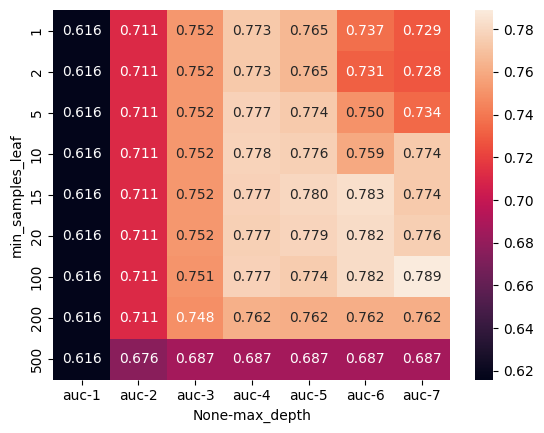

In [463]:
sns.heatmap(df_scores_pivot, annot=True, fmt=".3f")


 Based on the heatmap, we configure and train our final, optimized Decision Tree.

In [464]:
decision_tree = DecisionTreeClassifier(max_depth=7, min_samples_leaf=100)
decision_tree.fit(X_train, y_train)


DecisionTreeClassifier(max_depth=7, min_samples_leaf=100)

 ## 4. Random Forest

 A **Random Forest** is an ensemble method that aggregates multiple decision trees.



 Each tree in a Random Forest is trained independently on a random subset of features and data (Bagging). To make a final prediction, the forest averages the output probabilities of all its constituent trees. This prevents the overfitting common in single decision trees.

In [465]:
from sklearn.ensemble import RandomForestClassifier


 The `n_estimators` parameter specifies how many independent decision trees the forest should contain.

In [466]:
random_forest = RandomForestClassifier(n_estimators=10, random_state=1)
random_forest.fit(X_train, y_train)


RandomForestClassifier(n_estimators=10, random_state=1)

In [467]:
y_pred = random_forest.predict_proba(X_val)[:, 1]
roc_auc_score(y_val, y_pred)


np.float64(0.7841368878805067)

 Because feature selection in Random Forests is random, running it multiple times yields slightly different results. Setting `random_state=1` fixes the seed so our results are strictly reproducible.



 Let's observe how the model's AUC improves as we increase the number of trees (`n_estimators`) from 10 to 200.

In [468]:
scores = []

for n in range(10, 201, 10):

    random_forest = RandomForestClassifier(n_estimators=n, random_state=1)
    random_forest.fit(X_train, y_train)

    y_pred = random_forest.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, y_pred)

    scores.append((n, auc))


In [469]:
df_scores = pd.DataFrame(scores, columns=["number_of_trees", "auc"])


In [470]:
df_scores


,number_of_trees,auc
0,10,0.784137
1,20,0.799263
2,30,0.804922
3,40,0.809009
4,50,0.815037
5,60,0.815602
6,70,0.816181
7,80,0.814269
8,90,0.814143
9,100,0.815223


 Plotting this progression shows that performance generally increases with more trees, but eventually hits a plateau (diminishing returns).

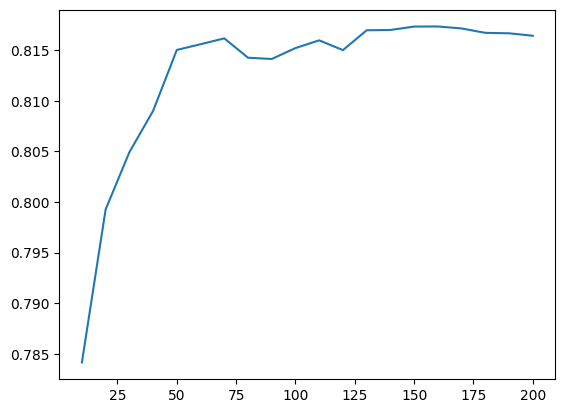

In [471]:
plt.plot(df_scores.number_of_trees, df_scores.auc)


 ### Hyperparameter Tuning (Random Forest)

 We observe that around `70` trees, the performance stabilizes. Let's fix `n_estimators` at 70 and tune the `max_depth` parameter for the internal trees.

In [472]:
number_of_trees = 70

scores = []

for n in range(10, 201, 10):
    for max_depth in [5, 6, 7, 8, 9, 10, 15, 20]:
        random_forest = RandomForestClassifier(n_estimators=n, random_state=1, max_depth=max_depth)
        random_forest.fit(X_train, y_train)

        y_pred = random_forest.predict_proba(X_val)[:, 1]
        auc = roc_auc_score(y_val, y_pred)

        scores.append((max_depth, n, auc))


In [473]:
columns = ["max_depth", "number_of_trees", "auc"]
df_scores = pd.DataFrame(scores, columns=columns)
df_scores.head()


,max_depth,number_of_trees,auc
0,5,10,0.811908
1,6,10,0.810805
2,7,10,0.807664
3,8,10,0.797529
4,9,10,0.802868


 Plotting the AUC curves for various depths allows us to visually isolate the best performing `max_depth`.

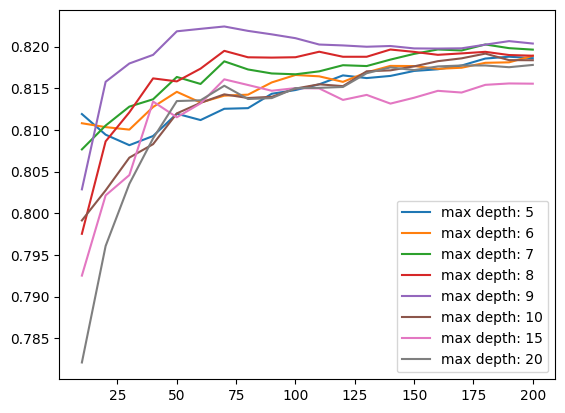

In [474]:
for max_depth in [5, 6, 7, 8, 9, 10, 15, 20]:
    df_subset = df_scores[df_scores.max_depth == max_depth]
    plt.plot(df_subset.number_of_trees, df_subset.auc, label=f"max depth: {max_depth}")

plt.legend()


 Based on the graph, `max_depth = 9` consistently performs the best. We fix this value and proceed to tune `min_samples_leaf`.

In [475]:
max_depth = 9

scores = []

for n in range(10, 201, 10):
    for min_samples_leaf in [1, 3, 5, 10, 15, 20, 100, 200]:
        random_forest = RandomForestClassifier(n_estimators=n, random_state=1, max_depth=max_depth, min_samples_leaf=min_samples_leaf)
        random_forest.fit(X_train, y_train)

        y_pred = random_forest.predict_proba(X_val)[:, 1]
        auc = roc_auc_score(y_val, y_pred)

        scores.append((min_samples_leaf, n, auc))


In [476]:
columns = ["min_samples_leaf", "number_of_trees", "auc"]
df_scores = pd.DataFrame(scores, columns=columns)
df_scores.head()


,min_samples_leaf,number_of_trees,auc
0,1,10,0.802868
1,3,10,0.806791
2,5,10,0.803895
3,10,10,0.805338
4,15,10,0.808275


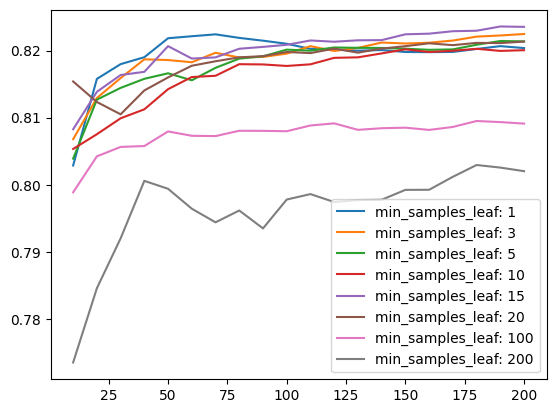

In [477]:
for min_samples_leaf in [1, 3, 5, 10, 15, 20, 100, 200]:
    df_subset = df_scores[df_scores.min_samples_leaf == min_samples_leaf]
    plt.plot(df_subset.number_of_trees, df_subset.auc, label=f"min_samples_leaf: {min_samples_leaf}")

plt.legend()


 We find that `min_samples_leaf = 3` yields the highest and most stable AUC. We configure and train our final optimized Random Forest model.



 *(Note: Other advanced parameters like `max_features` and `bootstrap` can also be tuned for marginal gains).*

In [478]:
min_samples_leaf = 3

random_forest = RandomForestClassifier(n_estimators=number_of_trees, random_state=1, max_depth=max_depth, min_samples_leaf=min_samples_leaf)
random_forest.fit(X_train, y_train)

y_pred = random_forest.predict_proba(X_val)[:, 1]
roc_auc_score(y_val, y_pred)


np.float64(0.8196760572256886)

 ## 5. Gradient Boosting (XGBoost)

 While Random Forest trains independent trees simultaneously, **Gradient Boosting** trains trees *sequentially*. Each new tree evaluates the errors of the entire system up to that point and is specifically designed to correct the mistakes made by the previous trees.



 We use the highly optimized `xgboost` library for this.

In [479]:
import xgboost as xgb


 XGBoost uses a proprietary, high-performance data structure called a **DMatrix**. We must convert our feature matrices into DMatrix objects before training.

In [480]:
features = list(dv.get_feature_names_out())
dtrain = xgb.DMatrix(X_train, label=y_train, feature_names=features)
dval = xgb.DMatrix(X_val, label=y_val, feature_names=features)


 ### Training the XGBoost Model

 We configure a parameter dictionary and train the model using `xgb.train()`. Important parameters include:

 * `eta`: Learning rate (step size).

 * `max_depth`: Controls the depth of the individual trees.

 * `min_child_weight`: The XGBoost equivalent of `min_samples_leaf`.

 * `objective`: The task type (`binary:logistic` outputs probabilities for binary classification).

 * `nthread`: Number of parallel CPU threads used for training.

In [481]:
xgb_params = {
    "eta": 0.3,
    "max_depth": 6,
    "min_child_weight": 1,

    "objective": "binary:logistic",
    "nthread": 8,
    
    "seed": 1,
    "verbosity":1
}

model = xgb.train(params=xgb_params, dtrain=dtrain, num_boost_round=16)


In [482]:
y_pred = model.predict(dval)


In [483]:
roc_auc_score(y_val, y_pred)


np.float64(0.8153746770025838)

 ### Monitoring Validation Score During Training

 XGBoost can natively evaluate its performance on a validation set *while* it is training. We pass a `watchlist` to the `evals` parameter and set `"eval_metric": "auc"` in our parameters.

In [484]:
watchlist = [(dtrain, "train"), (dval, "val")]


 By using the IPython magic command `%%capture output`, we can catch the printed text output of the training process and store it in a variable for later parsing.

In [485]:
%%capture output

xgb_params = {
    "eta": 0.3,
    "max_depth": 6,
    "min_child_weight": 1,

    "objective": "binary:logistic",
    "nthread": 8,
    "eval_metric":"auc",
    
    "seed": 1,
    "verbosity":1
}

model = xgb.train(params=xgb_params, dtrain=dtrain, num_boost_round=200, evals=watchlist)


 We write a custom function to parse the captured stdout string, extracting the iteration number, training AUC, and validation AUC into a structured Pandas DataFrame.

In [486]:
def parse_xgb_output(output):
    results = []

    for line in output.stdout.strip().split("\n"):
        it_line, train_line, val_line = line.split("\t")

        it = int(it_line.strip("[]"))
        train = float(train_line.split(":")[1])
        val = float(val_line.split(":")[1])

        results.append((it, train, val))

    columns = ["num_iter", "train_auc", "val_auc"]
    df_results = pd.DataFrame(results, columns=columns)
    return df_results


In [487]:
df_output = parse_xgb_output(output)


 Plotting the validation AUC over iterations shows if the model is learning effectively or if it is overfitting (indicated by a dropping curve in later rounds).

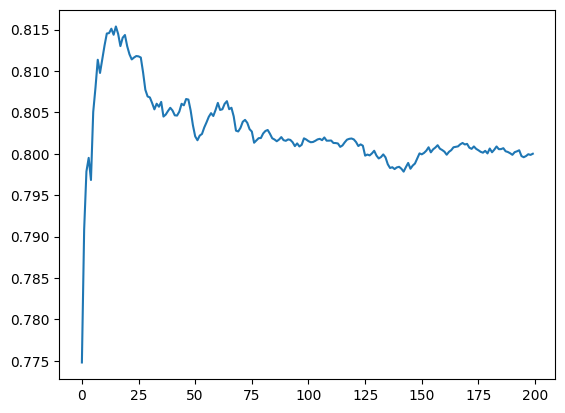

In [488]:
# plt.plot(df_output.num_iter, df_output.train_auc, label="train")
plt.plot(df_output.num_iter, df_output.val_auc, label="validation")
# plt.legend()


 ### Hyperparameter Tuning (XGBoost)

 We will now tune the Learning Rate (`eta`). We capture the output of different `eta` values and store them in a dictionary for comparison.

In [489]:
scores = {}


In [490]:
%%capture output

# tuning the parameters of the xgboost model:

xgb_params = {
    "eta": 0.01,
    "max_depth": 6,
    "min_child_weight": 1,

    "objective": "binary:logistic",
    "nthread": 8,
    "eval_metric":"auc",
    
    "seed": 1,
    "verbosity":1
}

model = xgb.train(params=xgb_params, dtrain=dtrain, num_boost_round=200, evals=watchlist)


In [491]:
key = f"eta={xgb_params['eta']}"
scores[key] = parse_xgb_output(output)


 Visualizing the effects of different Learning Rates (`eta`).

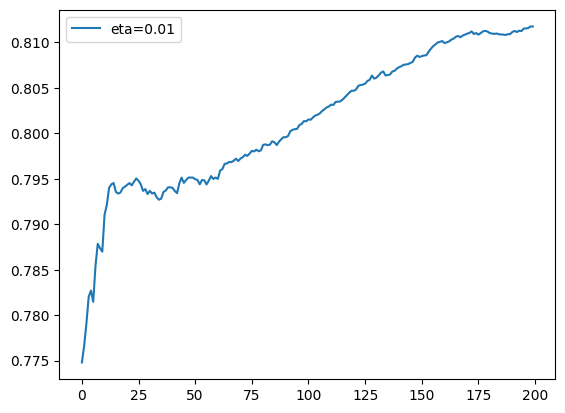

In [492]:
for key, df_scores in scores.items():
    plt.plot(df_scores.num_iter, df_scores.val_auc, label=key)

plt.legend()


 Based on experimentation, an `eta` (learning rate) of `0.1` strikes the best balance between learning speed and stability. We fix it at `0.1`.

In [493]:
# so, the best eta would be 0.1 for our model. 
eta = 0.1


 Next, we tune `max_depth` for our XGBoost trees.

In [494]:
scores = {}


In [495]:
%%capture output

xgb_params = {
    "eta": eta,
    "max_depth": 6,
    "min_child_weight": 1,

    "objective": "binary:logistic",
    "nthread": 8,
    "eval_metric":"auc",
    
    "seed": 1,
    "verbosity":1
}

model = xgb.train(params=xgb_params, dtrain=dtrain, num_boost_round=200, evals=watchlist)


In [496]:
key = f"max_depth={xgb_params['max_depth']}"
scores[key] = parse_xgb_output(output)


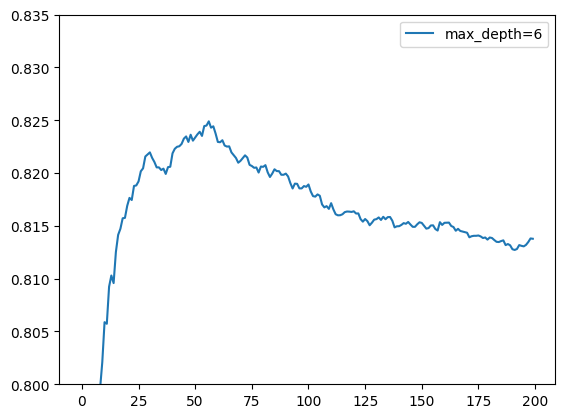

In [497]:
for key, df_scores in scores.items():
    plt.plot(df_scores.num_iter, df_scores.val_auc, label=key)

plt.ylim(0.8, 0.835)
plt.legend()


 We find that `max_depth = 3` produces the best AUC without overfitting. We lock it in and move to tuning `min_child_weight`.

In [498]:
# so, the best max_depth would be 3 for our model.
max_depth = 3


In [499]:
scores = {}


In [500]:
%%capture output

xgb_params = {
    "eta": eta,
    "max_depth": max_depth,
    "min_child_weight": 20,

    "objective": "binary:logistic",
    "nthread": 8,
    "eval_metric":"auc",
    
    "seed": 1,
    "verbosity":1
}

model = xgb.train(params=xgb_params, dtrain=dtrain, num_boost_round=200, evals=watchlist)


In [501]:
key = f"min_child_weight={xgb_params['min_child_weight']}"
scores[key] = parse_xgb_output(output)


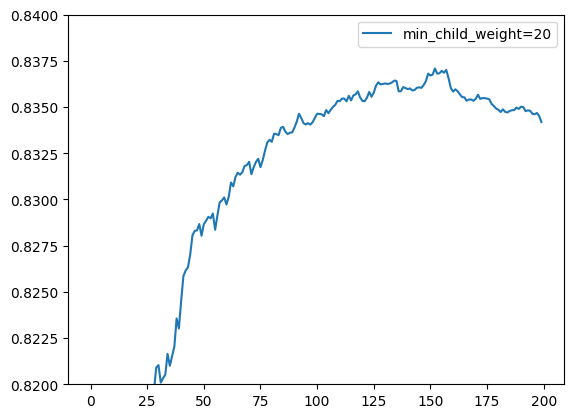

In [502]:
for key, df_scores in scores.items():
    plt.plot(df_scores.num_iter, df_scores.val_auc, label=key)

plt.ylim(0.82, 0.84)
plt.legend()


 The ideal `min_child_weight` is determined to be `15`.



 We train our final, fully optimized XGBoost model. (Note: other parameters like `subsample`, `colsample_bytree`, `lambda`, and `alpha` could also be tuned in a more exhaustive search).

In [503]:
# so, the best min_child_weight for our model is 15.
min_child_weight = 15


In [504]:
xgb_params = {
    "eta": eta,
    "max_depth": max_depth,
    "min_child_weight": min_child_weight,

    "objective": "binary:logistic",
    "nthread": 8,
    "eval_metric":"auc",
    
    "seed": 1,
    "verbosity":1
}

model = xgb.train(params=xgb_params, dtrain=dtrain, num_boost_round=125)
y_pred = model.predict(dval)
roc_auc_score(y_val, y_pred)


np.float64(0.8384697800466379)

 ## 6. Final Model Selection and Testing

 We have built and tuned three models. Now, we initialize them with their optimal parameters, train them side-by-side, and compare their validation AUCs.

In [505]:
# choosing the best model, decision tree, random forest or xgboost? 
decision_tree = DecisionTreeClassifier(max_depth=7, min_samples_leaf=100)
decision_tree.fit(X_train, y_train)

random_forest = RandomForestClassifier(n_estimators=70, random_state=1, max_depth=9, min_samples_leaf=3)
random_forest.fit(X_train, y_train)

xgb_params = {
    "eta": eta,
    "max_depth": max_depth,
    "min_child_weight": min_child_weight,

    "objective": "binary:logistic",
    "nthread": 8,
    "eval_metric":"auc",
    
    "seed": 1,
    "verbosity":1
}

model = xgb.train(params=xgb_params, dtrain=dtrain, num_boost_round=125)


 Retrieving the final comparison scores:

In [506]:
decision_tree_pred = decision_tree.predict_proba(X_val)[:, 1]
random_forest_pred = random_forest.predict_proba(X_val)[:, 1]
xgboost_pred = model.predict(dval)

print(f"""Decision Tree AUC: {roc_auc_score(y_val, decision_tree_pred)}
Random Forest AUC: {roc_auc_score(y_val, random_forest_pred)}
XGBoost AUC: {roc_auc_score(y_val, xgboost_pred)}""")


Decision Tree AUC: 0.7889802735236653
Random Forest AUC: 0.8196760572256886
XGBoost AUC: 0.8384697800466379


 ### Deployment to Test Data

 XGBoost emerged as the clear winner. To maximize its accuracy for the real world, we re-train it on the **combined Training and Validation dataset** (`df_full_train`).



 Finally, we evaluate this production-ready model on our hold-out Test dataset.

In [507]:
# so now that we see that the best model is xgboost, let's train it on our full_train dataset, and test it on the test dataset:
features = list(dv.get_feature_names_out())

df_full_train.reset_index(inplace=True, drop=True)
df_full_train.status = df_full_train.status.apply(lambda x: 0 if x == "ok" else 1)
y_full_train = df_full_train.status
del df_full_train["status"]
dicts_full_train = df_full_train.to_dict(orient="records")
dv = DictVectorizer(sparse=False)
X_full_train = dv.fit_transform(dicts_full_train)

d_full_train = xgb.DMatrix(X_full_train, label=y_full_train, feature_names=features)


In [508]:
test_dicts = df_test.to_dict(orient="records")
X_test = dv.transform(test_dicts)
dtest = xgb.DMatrix(X_test, label=y_test, feature_names=features)


In [509]:
xgb_params = {
    "eta": eta,
    "max_depth": max_depth,
    "min_child_weight": min_child_weight,

    "objective": "binary:logistic",
    "nthread": 8,
    "eval_metric":"auc",
    
    "seed": 1,
    "verbosity":1
}

model = xgb.train(params=xgb_params, dtrain=d_full_train, num_boost_round=125)


 Our final, rigorous evaluation metric on completely unseen data:

In [510]:
y_pred = model.predict(dtest)
roc_auc_score(y_test, y_pred)

np.float64(0.8227034947082901)